## 0. Landasan Teori

### a. Random Variable

### b. Term: PMF, PDF, dan CDF

### c. Distrbusi Normal Sebagai Bentuk Khusus dari Distribusi Variabel Acak Kontinu


## 1. Permasalahan

Suatu industri transportasi publik kelas internasional memerlukan standarisasi yang efisien terhadap dimensi dari desain ruang kaki (*legroom*) kursi berdasarkan tinggi penumpang untuk memastikan kenyamanan bagi mayoritas penumpang. Masalah muncul ketika desain kursi, khususnya pada perancangan ruang kaki (*legroom*) terasa terlalu sempit untuk orang yang tinggi.

Tujuan: Menentukan ambang batas ergonomi ruang kaki secara tepat untuk transportasi publik berdasarkan tinggi badan pria dewasa sebagai acuan agar harapannya dapat menjamin kenyamanan di atas 90% penumpang dan tetap dapat memudahkan proses produksi di ranah manufaktur.

## 2. Fokus Analisis

> Menurut Fukami, Ogata, dan Hattori (2025) rata-rata pria dewasa memiliki tinggi badan sekitar 13 cm lebih tinggi dibandingkan wanita dewasa. Perbedaan tinggi badan tersebut terutama disebabkan oleh pertumbuhan rangka yang lebih dominan pada laki-laki, yang dipengaruhi oleh hormon seks, khususnya androgen testikular, serta faktor genetik spesifik laki-laki. *Source*: (https://www.nature.com/articles/s10038-025-01384-4)


> Visualisasi Perbandingan Tinggi Rata-Rata Pria Dewasa dan Wanita Dewasa (Global):
> 
> 
> 
> <img src="../image/average-height-by-year-of-birth.png" width="500">
> 
> *Source*: (https://ourworldindata.org/human-height)


Penelitian ini berfokus pada tinggi pria di fase dewasa. Berdasarkan bukti perbandingan di atas, dengan menggunakan data pria dewasa sebagai basis desain batas atas, maka dapat dipastikan fasilitas akan secara inklusif memadai juga bagi hampir seluruh populasi wanita tanpa melakukan analisis ganda yang dapat bersifat redundan.

## 3. Definisi Peubah Acak

Peubah acak $X$ didefinisikan sebagai:
- $X$: tinggi badan pria dewasa (centimeter).
- $X$ tentunya bersifat kontinu karena data tinggi badan dapat diukur dalam skala desimal.
- Parameter Teoritis:
  - > Menurut Max Roser, Cameron Appel, dan Hannah Ritchie (2024) tinggi badan orang dewasa dalam suatu populasi kira-kira terdistribusi secara normal dan dipengaruhi oleh banyak faktor genetik serta lingkungan. *Source*: (https://ourworldindata.org/human-height)
  - > Menurut Max Roser, Cameron Appel, dan Hannah Ritchie (2024) rata-rata tinggi badan pria dewasa secara global adalah 178.4 cm dengan standar deviasi sebesar 7.59 cm. *Source*: (https://ourworldindata.org/human-height)
  - Sehingga dapat disimpulkan bahwa secara teoritis dan *global*, variabel acak $X$ berdistribusi normal dengan *mean* 178.4 $cm$ dan *varians* sebesar kuadrat dari 7.59 $cm$ atau sebesar 57.6081 $cm^2$. Sehingga secara notasi matematis dapat ditulis:
  
$$X \sim NOR(178.4, 57.6081)$$


## 4. Import Library

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

## 5. Simulasi Data berdasarkan Parameter Teoritis

In [ ]:
# generate 1000 sample data to represent population of passengers empirically 
np.random.seed(42)
data = np.random.normal(178.4, 7.59, 1000)
df = pd.DataFrame(data, columns=['Tinggi'])

In [20]:
# preview data
df.head()

,Tinggi
0,182.170060
1,177.350574
2,183.315956
3,189.959797
4,176.622776


## 6. Exploratory Data Analysis

***Theoritical Normal Distribution***

Secara **teoritis**, terdapat beberapa sifat yang harus dipenuhi oleh suatu variabel acak untuk dapat dikatakan bentuk distribusinya mengikuti distribusi normal:

- Bentuk distribusi data simetris.
- mean = median = modus.
- Kurva berbentuk lonceng (*bell shaped*).
- Secara fungsi kepadatan peluang (PDF) harus memenuhi:
$$f(x; \mu, \sigma) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{x - \mu}{\sigma} \right)^2}$$

- Rentang Variabel: $-\infty < x < \infty$
- Mean (Rataan): $-\infty < \mu < \infty$ 
- Standar Deviasi: $\sigma > 0$ 
- Konstanta: $\pi \approx 3.14159$ dan $e \approx 2.71828$
  

Catatan: 
- Di dunia nyata **tidak ada** suatu peristiwa yang terdistribusi normal secara **sempurna**.
- Distribusi normal digunakan bukan karena ia merepresentasikan kenyataan secara mutlak, melainkan sebagai pendekatan (*proxy*) yang paling efisien untuk memahami kecenderungan umum dari populasi yang besar.

Text(0.5, 1.0, 'Distribusi Tinggi Badan Pria (Simulasi Empiris)')

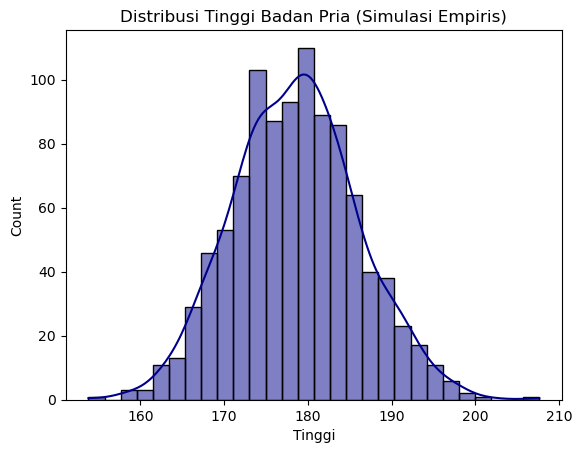

In [ ]:
# normality test: histogram
sns.histplot(df['Tinggi'], kde=True, color='darkblue')
plt.title("Distribusi Tinggi Badan Pria (Simulasi Empiris)")

Inference:
- Berdasarkan hasil visualisasi histogram di atas, distribusi tinggi badan pria menunjukkan kecenderungan normal secara empiris. Hal ini didasarkan pada bentuk kurva yang mendekati simetris dan terpusat pada satu puncak tunggal.

In [ ]:
# normality test: Shapiro-Wilk
stat, p = stats.shapiro(df['Tinggi'])
print(f"P-value: {p:.4f}")

P-value: 0.6273


Inference:
- Dikarenakan nilai p-value lebih dari 5%, maka berdasarkan uji Shapiro-Wilk dapat dikatakan bahwa distribusi data tinggi badan pria dewasa mengikuti normal/gaussian.

Dikarenakan data mengikuti distribusi normal, maka kita bisa memanfaatkan teorema *empirical rule* untuk mendapatkan *insight* lebih dari data.

In [23]:
mu = df['Tinggi'].mean()
sigma = df['Tinggi'].std()

print("============ PENYEBARAN DATA BERDASARKAN EMPIRICAL RULE ============")
print(f"Sekitar 68% data berada di antara: {mu - 1*sigma:.2f} - {mu + 1*sigma:.2f} cm")
print(f"Sekitar 95% data berada di antara: {mu - 2*sigma:.2f} - {mu + 2*sigma:.2f} cm")
print(f"Sekitar 99.7% data berada di antara: {mu - 3*sigma:.2f} - {mu + 3*sigma:.2f} cm")

============ PENYEBARAN DATA BERDASARKAN EMPIRICAL RULE ============
Sekitar 68% data berada di antara: 171.11 - 185.98 cm
Sekitar 95% data berada di antara: 163.68 - 193.41 cm
Sekitar 99.7% data berada di antara: 156.25 - 200.84 cm


## 7. Pembahasan Utama $-$ #1

In [ ]:
# define subprogram for formula implementation
def pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)
def cdf(x, mu, sigma):
    return stats.norm.cdf(x, mu, sigma)

In [ ]:
# threshold using 95% percentile
p95 = np.percentile(df['Tinggi'], 95)
print(f"Batas tinggi badan untuk 95% populasi: {p95:.2f} cm")

Batas tinggi badan untuk 95% populasi: 191.13 cm


Inference:
- Berdasarkan *domain knowledge*, untuk kemudahan produksi desain, standar dimensi fisik biasanya menggunakan kelipatan 5 atau 10 untuk efisiensi proses manufaktur.
- Oleh karena itu, secara praktikal akan ditetapkan ambang batas-nya bernilai 190 $cm$.

Untuk mengetahui seberapa besar risiko penumpang yang tidak terakomodasi oleh standar *legroom* untuk 190 $cm$, kita menggunakan rumus peluang komplemen dan tentunya dengan bantuan kalkulasi dari fungsi distribusi kumulatif (CDF):

$$P(X > 190) = 1 - P(X \leq 190)$$

Inference:
Yang dilakukan di atas artinya, kita menghitung sisa populasi yang berada di luar batas kenyamanan yang telah ditetapkan.

In [26]:
threshold = 190
prob_lebih_190 = 1 - cdf(190, mu, sigma)
print(f"Peluang Tinggi Pria > 190 cm: {prob_lebih_190*100:.2f}%")

Peluang Tinggi Pria > 190 cm: 6.17%


Inference:

Jika perusahaan memutuskan untuk menggunakan standar 190 $cm$, maka secara perhitungan peluang di atas akan terdapat sekitar 6.17% penumpang pria yang akan merasa kesempitan. Angka ini adalah *trade-off* yang kita terima agar kapasitas kursi di dalam armada tetap maksimal. Dengan kata lain, desain ini memiliki tingkat kesuksesan  sekitar 93.83%, yang secara industri seharusnya sudah dianggap cukup memenuhi standar kenyamanan massal.

## 8. Pembahasan Utama $-$ #2

In [ ]:
varians_empiris = df['Tinggi'].var()
print(f"--- Mean, Var, Std-Dev Data Simulasi (EMPIRIS) ---")
print(f"Mean (E[X])      : {mu:.2f} cm")
print(f"Varians (Var[X]) : {varians_empiris:.2f}")
print(f"Std. Deviasi     : {sigma:.2f}")

--- Mean, Var, Std-Dev Data Simulasi ---
Mean (E[X])      : 178.55 cm
Varians (Var[X]) : 55.24
Std. Deviasi     : 7.43


menggunakan nilai di atas untuk menghitung kasus peluang yang sama dengan **pendekatan normal baku** (Z-Score) yang lebih eksplisit :
$$Z = \frac{X - E[X]}{\sigma}$$

1. Substitusi Nilai ke Rumus Z:
   $$Z = \frac{190 - 178.55}{7.43}$$
   $$Z = \frac{11.45}{7.43} \approx 1.54$$

2. Menentukan Peluang $P(X > 190)$:
   
   Karena tabel distribusi normal standar biasanya menunjukkan area di sebelah kiri ($P(Z < z)$), maka:
   $$P(X > 190) = P(Z > 1.54)$$
   $$P(Z > 1.54) = 1 - P(Z < 1.54)$$

In [28]:
z_score = (threshold - mu) / sigma
p_kumulatif = stats.norm.cdf(z_score)
p_risiko = 1 - p_kumulatif
print(f"Hasil Perhitungan Normal Baku:")
print(f"Nilai Z-score         : {z_score:.4f}")
print(f"P(Z <= {z_score:.2f}) (Muat)  : {p_kumulatif:.2%}")
print(f"P(Z > {z_score:.2f}) (Gagal) : {p_risiko:.2%}")

Hasil Perhitungan Normal Baku:
Nilai Z-score         : 1.5410
P(Z <= 1.54) (Muat)  : 93.83%
P(Z > 1.54) (Gagal) : 6.17%


## 9. Kesimpulan

Desain *legroom* dengan standar 190 $cm$ pria dewasa memiliki tingkat inklusivitas sebesar 93.83%, di mana hanya terdapat risiko sebesar 6.17% penumpang (kelompok dengan tinggi badan ekstrem) yang mungkin merasa kurang nyaman. Secara analitik, keputusan ini dianggap sangat ideal karena berhasil mengakomodasi mayoritas besar populasi tanpa mengorbankan terlalu banyak ruang yang bisa berdampak pada penurunan kapasitas total armada. Sebagai rekomendasi tambahan dari kami, kelompok berisiko sekitar 6% ini dapat diarahkan pada area kursi khusus dengan ruang ekstra, sehingga efisiensi desain massal tetap terjaga tanpa mengabaikan aspek kenyamanan.

## 10. Catatan Kaki

1) https://www.google.com/url?q=https%3A%2F%2Fwww.probabilitycourse.com%2Fchapter4%2F4_1_1_pdf.php
2) https://youtu.be/xlxaa9YhT6A?si=GglKbzQ2hBxOpQe0